In [1]:
%load_ext watermark


In [2]:
import os
import subprocess

os.environ["POLARS_FORCE_NEW_STREAMING"] = "1"

from IPython.display import display, HTML
import numpy as np
import pandas as pd
import polars as pl
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-05-21T05:50:45.228214+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1027-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

pandas : 2.2.3
scipy  : 1.14.1
polars : 1.29.0
numpy  : 2.1.2
teeplot: 1.4.2
seaborn: 0.13.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-05-19-freqscreen-summary"
teeplot_subdir


'2025-05-19-freqscreen-summary'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
data_sources = {
    # "dummy": "https://osf.io/cjqx2/download",
    "uk-big": "https://osf.io/pgj7t/download",
    "uk": "https://osf.io/mkjy5/download",
    "multistrain": "https://osf.io/ywmpt/download",
    "vanilla": "https://osf.io/r8skg/download",
    "vanilla-big": "https://osf.io/j4795/download",
    "vanilla-big-1.3x": "https://osf.io/cnp5z/download",
}
tmp_path = f"/tmp/{teeplot_subdir}.pqt"


In [7]:
results = []

for source_name, url in data_sources.items():
    print(f"Downloading {source_name} data from {url}")

    subprocess.run(
        [
            "wget",
            "--tries=5",
            "--show-progress",
            "--progress=bar:force",
            "-O",
            str(tmp_path),
            url,
        ],
        check=True,
    )
    print("done!")

    df = pl.scan_parquet(
        tmp_path,
        low_memory=True,
        retries=5,
    )

    unique_groups = (
        df.unique(
            [
                "trt_name",
                "trt_n_downsample",
                "trt_hsurf_bits",
                "replicate_uuid",
            ]
        )
        .select(
            pl.col("trt_name"),
            pl.col("trt_n_downsample"),
            pl.col("trt_hsurf_bits"),
            pl.col("replicate_uuid"),
        )
        .drop_nans()
        .drop_nulls()
        .collect(engine="streaming")
    )

    for (trt_name, trt_n_downsample, trt_hsurf_bits, replicate_uuid) in tqdm(
        [*unique_groups.iter_rows()],
    ):
        phylo_df = (
            df.filter(
                (pl.col("trt_name") == trt_name)
                & (pl.col("trt_n_downsample") == trt_n_downsample)
                & (pl.col("trt_hsurf_bits") == trt_hsurf_bits)
                & (pl.col("replicate_uuid") == replicate_uuid)
            )
            .collect(engine="streaming")
            .to_pandas()
        )

        num_muts = phylo_df["defmut_mask_sum"].astype(bool).sum()
        num_focal_muts = phylo_df["is_focal_defmut"].sum()
        num_bg_sites = phylo_df["cfg_maxseqlen"].unique().item()

        expected_num_muts = (
            phylo_df["defmut_mask_sum"].sum() - num_focal_muts
        ) / num_bg_sites

        lambda_poisson = expected_num_muts
        p_poisson = scipy_stats.poisson.sf(num_focal_muts, lambda_poisson)

        results.append(
            {
                "source_name": source_name,
                "trt_name": trt_name,
                "trt_n_downsample": trt_n_downsample,
                "trt_hsurf_bits": trt_hsurf_bits,
                "replicate_uuid": replicate_uuid,
                "num_muts": num_muts,
                "num_focal_muts": num_focal_muts,
                "num_bg_sites": num_bg_sites,
                "expected_num_muts": expected_num_muts,
                "p_poisson": p_poisson,
                "lambda_poisson": lambda_poisson,
            }
        )


--2025-05-21 05:50:45--  https://osf.io/pgj7t/download
Resolving osf.io (osf.io)... 35.190.84.173
Connecting to osf.io (osf.io)|35.190.84.173|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682d5f8cc1a255a482f08030?action=download&direct&version=1 [following]
--2025-05-21 05:50:45--  https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682d5f8cc1a255a482f08030?action=download&direct&version=1
Resolving files.osf.io (files.osf.io)... 35.186.214.196
Connecting to files.osf.io (files.osf.io)|35.186.214.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 875499626 (835M) [application/octet-stream]
Saving to: ‘/tmp/2025-05-19-freqscreen-summary.pqt’

/tmp/2025-05-19-fre 100%[===================>] 834.94M  23.7MB/s    in 76s     

2025-05-21 05:52:03 (11.0 MB/s) - ‘/tmp/2025-05-19-freqscreen-summary.pqt’ saved [875499626/875499626]



done!


100%|██████████| 70/70 [01:16<00:00,  1.10s/it]
--2025-05-21 05:53:20--  https://osf.io/mkjy5/download
Resolving osf.io (osf.io)... 

35.190.84.173
Connecting to osf.io (osf.io)|35.190.84.173|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682c8b8ca9789d8b628f3f38?action=download&direct&version=1 [following]
--2025-05-21 05:53:20--  https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682c8b8ca9789d8b628f3f38?action=download&direct&version=1
Resolving files.osf.io (files.osf.io)... 35.186.214.196
Connecting to files.osf.io (files.osf.io)|35.186.214.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 201771388 (192M) [application/octet-stream]
Saving to: ‘/tmp/2025-05-19-freqscreen-summary.pqt’

/tmp/2025-05-19-fre 100%[===================>] 192.42M  64.1MB/s    in 3.0s    

2025-05-21 05:53:24 (64.1 MB/s) - ‘/tmp/2025-05-19-freqscreen-summary.pqt’ saved [201771388/201771388]



done!


...

done!


100%|██████████| 18/18 [00:11<00:00,  1.53it/s]
--2025-05-21 05:56:47--  https://osf.io/cnp5z/download
Resolving osf.io (osf.io)... 

35.190.84.173
Connecting to osf.io (osf.io)|35.190.84.173|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682caa9fbb3f815770b06c6b?action=download&direct&version=1 [following]
--2025-05-21 05:56:47--  https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682caa9fbb3f815770b06c6b?action=download&direct&version=1
Resolving files.osf.io (files.osf.io)... 35.186.214.196
Connecting to files.osf.io (files.osf.io)|35.186.214.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 801307036 (764M) [application/octet-stream]
Saving to: ‘/tmp/2025-05-19-freqscreen-summary.pqt’

/tmp/2025-05-19-fre 100%[===================>] 764.19M  69.7MB/s    in 10s     

2025-05-21 05:56:59 (76.2 MB/s) - ‘/tmp/2025-05-19-freqscreen-summary.pqt’ saved [801307036/801307036]



done!


100%|██████████| 20/20 [00:19<00:00,  1.00it/s]


In [8]:
results_df = pd.DataFrame(results)
results_df


,source_name,trt_name,trt_n_downsample,trt_hsurf_bits,replicate_uuid,num_muts,num_focal_muts,num_bg_sites,expected_num_muts,p_poisson,lambda_poisson
0,uk-big,Sben2x/Gdel2x,1000000,0,02e78687-647f-8589-871d-69d40c582380,1957,1498,19.0,24.473684,0.000000e+00,24.473684
1,uk-big,Sben1.1x/Gneu,1000000,0,1be1111a-1a80-8082-bbec-82cc6c17c491,556,4,19.0,29.105263,1.000000e+00,29.105263
2,uk-big,Sben1.1x/Gneu,1000000,64,1be1111a-1a80-8082-bbec-82cc6c17c491,574,4,19.0,30.000000,1.000000e+00,30.000000
3,uk-big,Sben1.1x/Gneu,1000000,0,22dda61e-4644-8282-834c-c47d0491981d,505,7,19.0,26.210526,9.999906e-01,26.210526
4,uk-big,Sben1.1x/Gneu,1000000,64,22dda61e-4644-8282-834c-c47d0491981d,510,5,19.0,26.578947,9.999996e-01,26.578947
...,...,...,...,...,...,...,...,...,...,...,...
242,vanilla-big-1.3x,Sben1.3x/Gdel1.3x,2000000,0,c8b6eec3-f562-8a2a-a720-f23d4acf1d94,5808,1327,19.0,236.315789,0.000000e+00,236.315789
243,vanilla-big-1.3x,Sben1.3x/Gdel1.3x,200000,0,cb422b5d-9a74-87e8-9654-9bc12d44b453,1171,235,19.0,49.578947,3.636375e-81,49.578947
244,vanilla-big-1.3x,Sben1.3x/Gdel1.3x,2000000,0,cb422b5d-9a74-87e8-9654-9bc12d44b453,5817,1270,19.0,240.000000,0.000000e+00,240.000000
245,vanilla-big-1.3x,Sben1.3x/Gneu,2000000,0,488c314a-7dbc-88f3-aa36-beada5f1bb05,6215,1807,19.0,232.631579,0.000000e+00,232.631579


In [9]:
results_df["trt_name_"] = results_df["trt_name"].str.replace("/", "\n")


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+row=source-name+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+row=source-name+viz=catplot+y=p-poisson+ext=.png


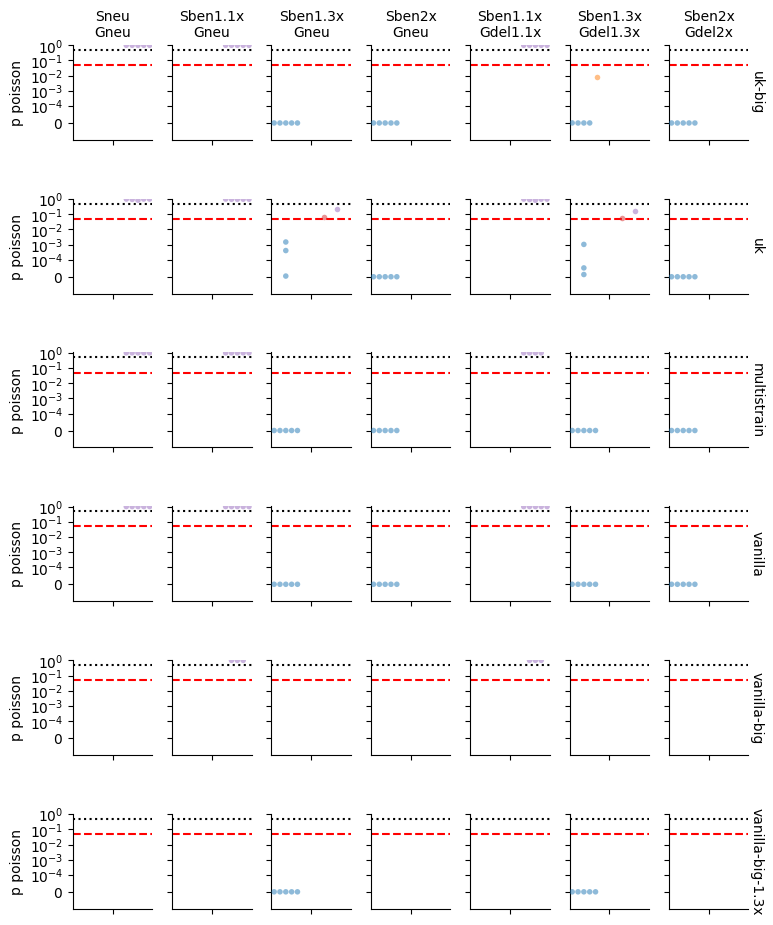

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=multistrain+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=multistrain+viz=catplot+y=p-poisson+ext=.png


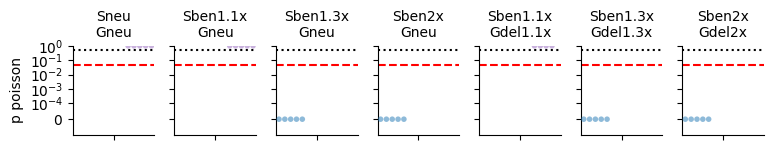

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=uk+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=uk+viz=catplot+y=p-poisson+ext=.png


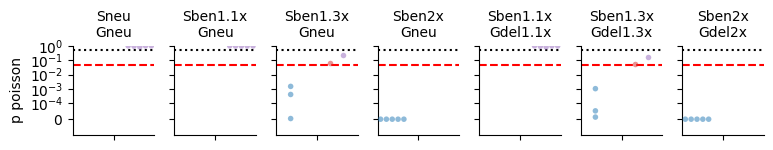

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=uk-big+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=uk-big+viz=catplot+y=p-poisson+ext=.png


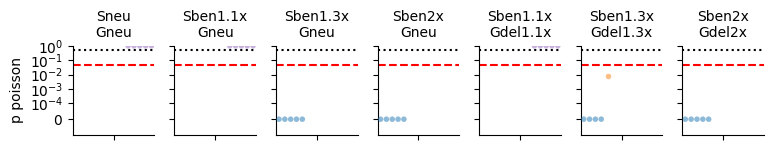

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla+viz=catplot+y=p-poisson+ext=.png


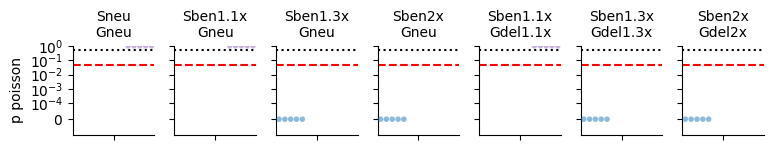

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla-big+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla-big+viz=catplot+y=p-poisson+ext=.png


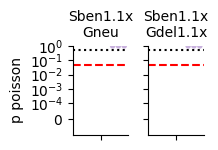

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla-big-1.3x+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla-big-1.3x+viz=catplot+y=p-poisson+ext=.png


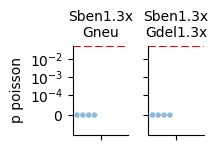

In [10]:
bins = [-np.inf, 0.005, 0.01, 0.05, 0.1, np.inf]
labels = ["<0.005", "<0.01", "<0.05", "<0.1", "ns"]

for y in ("p_poisson",):
    display(HTML(f"<h1>{y=}</h1>"))

    data = results_df[
        (results_df["trt_hsurf_bits"] == 0)
        & (
            results_df["trt_n_downsample"]
            == results_df
            .groupby(["trt_name","source_name"])["trt_n_downsample"]
            .transform("max")
        )
    ].copy()
    data["sig"] = pd.cut(
        data[y],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )
    data["sig"] = data["sig"].cat.set_categories(labels, ordered=True)
    col_order = filter(
        set(data["trt_name_"]).__contains__,
        [
            "Sneu\nGneu",
            "Sben1.1x\nGneu",
            "Sben1.3x\nGneu",
            "Sben2x\nGneu",
            "Sben1.1x\nGdel1.1x",
            "Sben1.3x\nGdel1.3x",
            "Sben2x\nGdel2x",
        ],
    )
    col_order = [*col_order]
    with tp.teed(
        sns.catplot,
        data=data,
        y=y,
        col="trt_name_",
        row="source_name",
        hue="sig",
        col_order=col_order,
        legend=False,
        kind="swarm",
        dodge=True,
        margin_titles=True,
        alpha=0.5,
        height=1.6,
        aspect=0.7,
        size=4,
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(0.5, color="black", linestyle=":")
            ax.axhline(0.05, color="red", linestyle="--")
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()

    for source_name, group_df in data.groupby("source_name"):
        with tp.teed(
            sns.catplot,
            data=group_df,
            y=y,
            col="trt_name_",
            hue="sig",
            col_order=filter(
               set(group_df["trt_name_"]).__contains__,
               col_order,
            ),
            legend=False,
            kind="swarm",
            dodge=True,
            margin_titles=True,
            alpha=0.5,
            height=1.6,
            aspect=0.7,
            size=4,
            teeplot_outattrs={"source_name": source_name},
            teeplot_subdir=teeplot_subdir,
        ) as teed:
            teed.set_titles(col_template="{col_name}", row_template="{row_name}")
            for ax in teed.axes.flat:
                ax.set_yscale("symlog", linthresh=0.0001)
                ax.set_ylim(-0.0001, None)
                ax.axhline(0.5, color="black", linestyle=":")
                ax.axhline(0.05, color="red", linestyle="--")
                ax.tick_params(axis="x", rotation=-60)
                ax.set_xlabel("")
                ax.set_ylabel(y.replace("_", " "))

            teed.tight_layout()


teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+row=source-name+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+row=source-name+viz=catplot+y=num-focal-muts+ext=.png


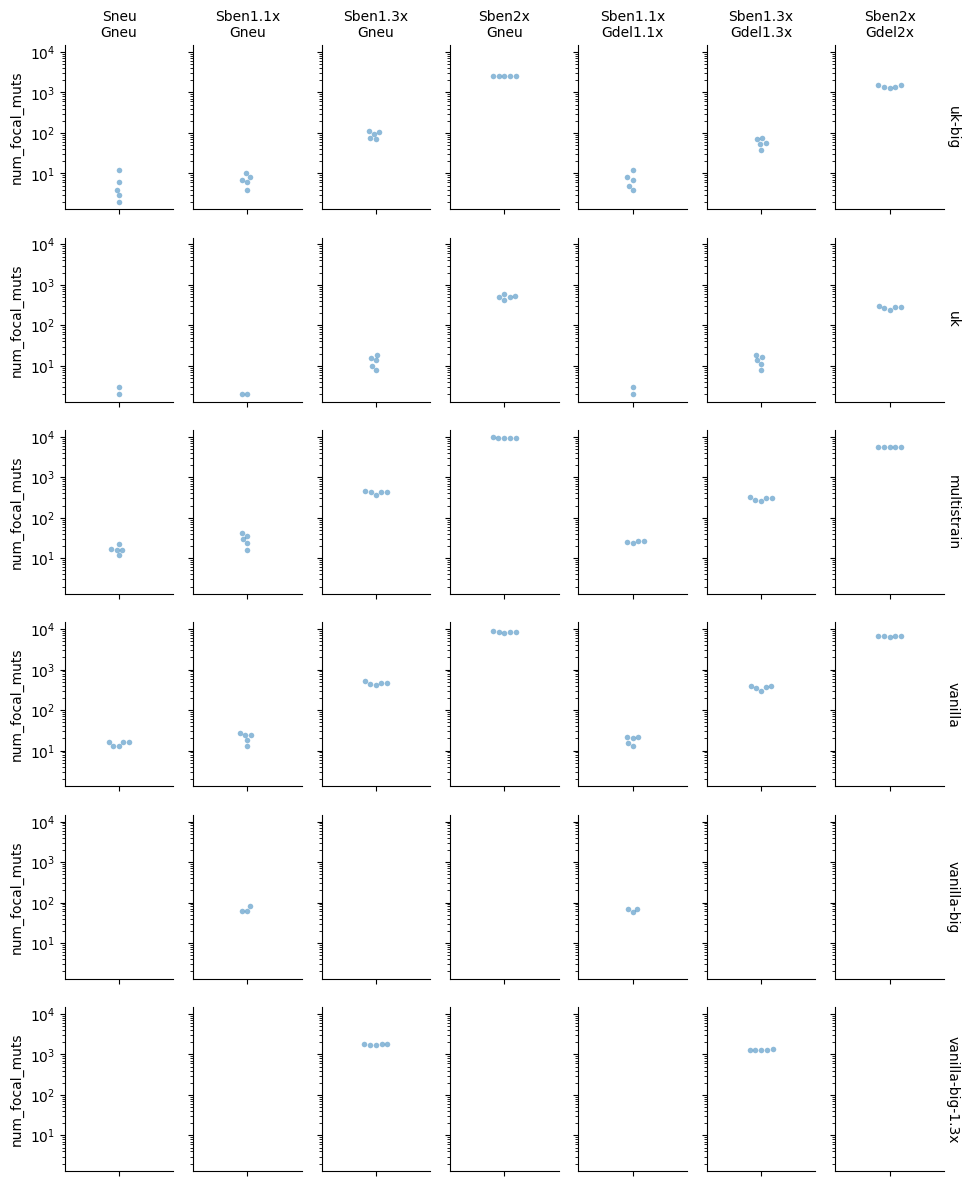

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=multistrain+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=multistrain+viz=catplot+y=num-focal-muts+ext=.png


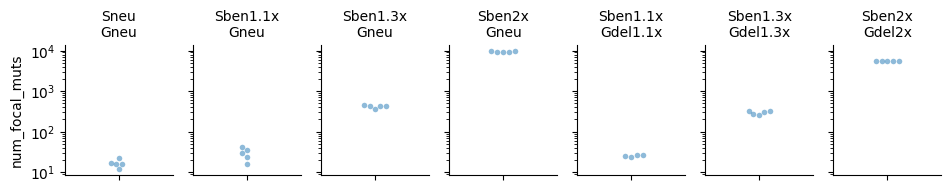

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=uk+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=uk+viz=catplot+y=num-focal-muts+ext=.png


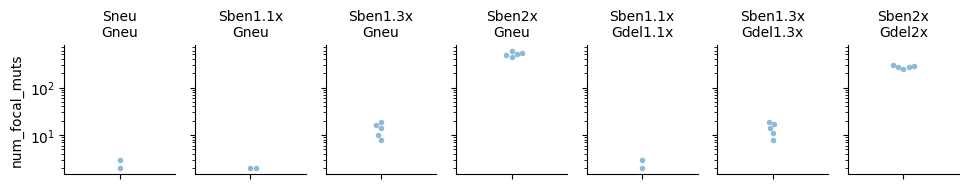

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=uk-big+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=uk-big+viz=catplot+y=num-focal-muts+ext=.png


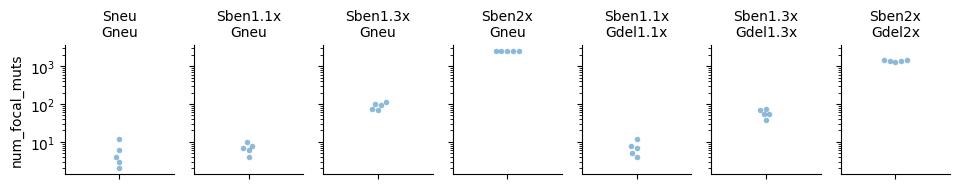

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla+viz=catplot+y=num-focal-muts+ext=.png


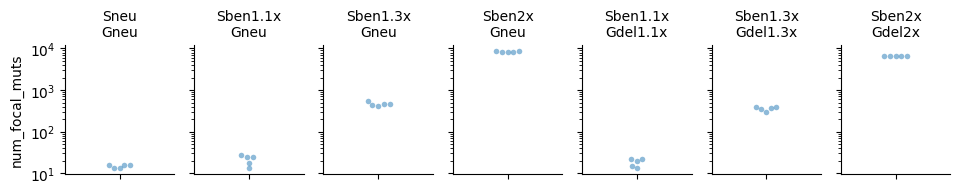

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla-big+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla-big+viz=catplot+y=num-focal-muts+ext=.png


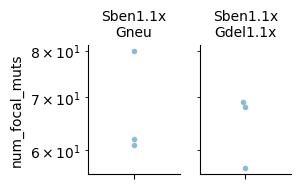

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla-big-1.3x+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla-big-1.3x+viz=catplot+y=num-focal-muts+ext=.png


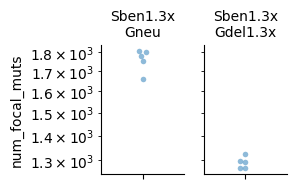

In [11]:
data = results_df[
    (results_df["trt_hsurf_bits"] == 0)
    & (
        results_df["trt_n_downsample"]
        == results_df
        .groupby(["trt_name","source_name"])["trt_n_downsample"]
        .transform("max")
    )
]

with tp.teed(
    sns.catplot,
    data=data,
    y="num_focal_muts",
    col="trt_name_",
    row="source_name",
    col_order=col_order,
    legend=False,
    kind="swarm",
    dodge=True,
    margin_titles=True,
    alpha=0.5,
    height=2,
    aspect=0.7,
    size=4,
    teeplot_subdir=teeplot_subdir,
) as teed:
    teed.set_titles(col_template="{col_name}", row_template="{row_name}")
    for ax in teed.axes.flat:
        ax.set_yscale("log")

        ax.set_xlabel("")

    teed.tight_layout()

for source_name, group_df in data.groupby("source_name"):
    with tp.teed(
        sns.catplot,
        data=group_df,
        y="num_focal_muts",
        col="trt_name_",
        col_order=filter(set(group_df["trt_name_"]).__contains__, col_order),
        legend=False,
        kind="swarm",
        dodge=True,
        margin_titles=True,
        alpha=0.5,
        height=2,
        aspect=0.7,
        size=4,
        teeplot_outattrs={"source_name": source_name},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("log")

            ax.set_xlabel("")
